In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torch
import torch.nn as nn
from diffusers import DPMSolverMultistepScheduler
from optimum.intel import OVStableDiffusionInpaintPipeline
from ultralytics.models.sam import SAM

Multiple distributions found for package optimum. Picked distribution: optimum
c:\Users\zeyad\miniconda3\envs\multimodal\Lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(



0: 1024x1024 1 0, 1449.9ms
Speed: 18.9ms preprocess, 1449.9ms inference, 9.9ms postprocess per image at shape (1, 3, 1024, 1024)


(np.float64(-0.5), np.float64(1183.5), np.float64(789.5), np.float64(-0.5))

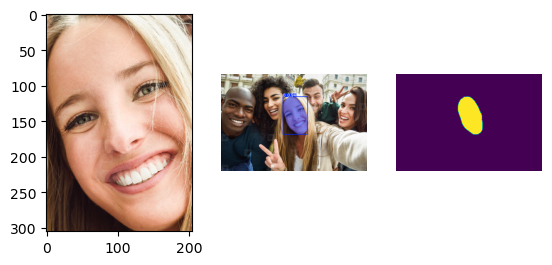

In [3]:
img_path = "../data/dummy_selfie.png"
bbox = [501, 188, 706, 493]
bigger_bbox = [350, 38, 856, 643]

orig_img = Image.open(img_path)


plt.subplot(131)
plt.imshow(np.array(orig_img)[bbox[1]:bbox[3], bbox[0]:bbox[2]])
seg_model = SAM("mobile_sam.pt")

segmentation_results = seg_model(orig_img, bboxes=[bbox])[0]
masks = segmentation_results.masks.data

plt.subplot(132)
plt.imshow(segmentation_results.plot()[:, :, ::-1])
plt.axis("off")

plt.subplot(133)
plt.imshow(masks[0].numpy())
plt.axis("off")

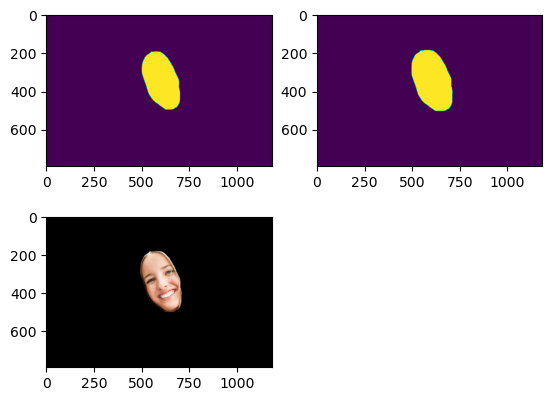

In [4]:
mask_np = masks[0].numpy().astype(np.uint8)

kernel = np.ones((15, 15), np.uint8)
dilated_mask = cv2.dilate(mask_np, kernel, iterations=1)

mask_img = Image.fromarray(dilated_mask * 255)
plt.subplot(221)
plt.imshow(mask_np)

plt.subplot(222)
plt.imshow(dilated_mask * 255)

plt.subplot(223)
plt.imshow(dilated_mask[:, :, None] * np.array(orig_img))

In [5]:
diffuser_model = OVStableDiffusionInpaintPipeline.from_pretrained("../checkpoints/ov_sd15_inpaint")
diffuser_model.scheduler = DPMSolverMultistepScheduler.from_config(diffuser_model.scheduler.config)

In [6]:
def inpaint_crop_stitch(orig_img, bbox):
    x1, y1, x2, y2 = bbox
    # Ensure we stay within bounds
    cropped_img = orig_img[y1:y2, x1:x2]

    # Use PIL for resizing to ensure compatibility
    resized_img = Image.fromarray(cropped_img).resize((100, 100), Image.LANCZOS)

    # Create a white PIL mask (255 = area to change)
    # Using np.ones((100,100)) * 255 as uint8
    mask_img = Image.fromarray((np.ones((100, 100)) * 255).astype(np.uint8))

    prompt = "high-quality cinematic portrait of an evil vampire, pale skin, red eyes, fangs, hyperrealistic, 8k, detailed skin texture"
    negative_prompt = "deformed, blurry, low quality, cartoon, bad anatomy"

    result = diffuser_model(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=resized_img,
        mask_image=mask_img,  # Now a PIL Image
        strength=0.75,
        guidance_scale=7.5,
        num_inference_steps=25,
    ).images[0]

    return result


result = inpaint_crop_stitch(np.array(orig_img), bbox)

  0%|          | 0/18 [00:00<?, ?it/s]

In [64]:
prompt = "high-quality cinematic portrait of an evil vampire, pale skin, red eyes, fangs, hyperrealistic, 8k, detailed skin texture"
negative_prompt = "deformed, blurry, low quality, cartoon, bad anatomy"

result = diffuser_model(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=orig_img,
    mask_image=mask_img,
    strength=0.75,          # Crucial: 0.75-0.80 keeps anatomy but changes identity
    guidance_scale=7.5,     # Lower CFG prevents "deep fried" over-saturated pixels
    num_inference_steps=25, # DPM Solver works great at 25 steps
).images[0]

  0%|          | 0/25 [00:00<?, ?it/s]

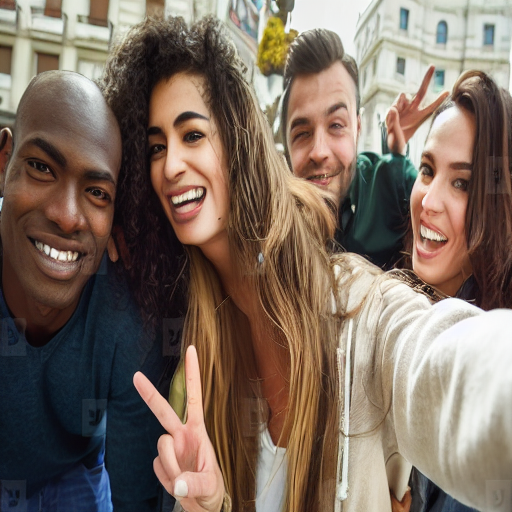

In [ ]:
result # wot

In [85]:
def inpaint_face_high_res(pipeline, orig_img, mask_np, prompt, negative_prompt):
    # 1. Get Bounding Box from SAM mask
    coords = np.argwhere(mask_np)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    
    # Add padding so the model sees the head/neck context (crucial for realism)
    pad = 100 
    img_w, img_h = orig_img.size
    y0, x0 = max(0, y0-pad), max(0, x0-pad)
    y1, x1 = min(img_h, y1+pad), min(img_w, x1+pad)
    
    # 2. Crop and Resize to 512x512 (Native SD 1.5 Resolution)
    crop_img = orig_img.crop((x0, y0, x1, y1)).resize((512, 512), Image.LANCZOS)
    crop_mask = Image.fromarray(mask_np[y0:y1, x0:x1]).resize((512, 512), Image.NEAREST)
    
    # 3. Inpaint the CROP only
    # At 512x512, the model has enough "room" to draw skin pores, eyes, and fangs.
    inpainted_crop = pipeline(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=crop_img,
        mask_image=crop_mask,
        strength=0.8,
        guidance_scale=7.5,
        num_inference_steps=30
    ).images[0]
    
    # 4. Stitch back into original image
    # Resize crop back to original dimensions
    inpainted_crop_resized = inpainted_crop.resize((x1-x0, y1-y0), Image.LANCZOS)
    
    final_img = orig_img.copy()
    # Use a blurred version of the mask for seamless blending
    mask_patch = mask_np[y0:y1, x0:x1].astype(np.float32)
    mask_patch = cv2.GaussianBlur(mask_patch, (15, 15), 0)
    
    # Simple alpha blending
    source = np.array(inpainted_crop_resized)
    target = np.array(final_img.crop((x0, y0, x1, y1)))
    mask_3d = np.repeat(mask_patch[:, :, np.newaxis], 3, axis=2)
    
    blended = (source * mask_3d + target * (1 - mask_3d)).astype(np.uint8)
    final_img.paste(Image.fromarray(blended), (x0, y0))
    
    return final_img

# Execute
result = inpaint_face_high_res(diffuser_model, orig_img, masks[0].cpu().numpy(), prompt, negative_prompt)
result.show()

RuntimeError: Exception from src\inference\src\cpp\infer_request.cpp:224:
Exception from src\plugins\intel_cpu\src\node.cpp:792:
[CPU] Convolution node with name '__module.encoder.conv_in/aten::_convolution/Convolution' Check 'ptr' failed at src\plugins\intel_cpu\src\cpu_memory.cpp:257:
Failed to allocate 68719476736 bytes of memory


